In [1]:
import scanpy as sc
import numpy as np
import anndata as ad
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

In [2]:
# load data
data_dir = '../data/frangieh/'
adata = sc.read_h5ad(data_dir + 'adata_preprocessed.h5ad')

In [3]:
# split data by condition
adata_control = adata[adata.obs['condition'] == 'Control']
adata_ifng = adata[adata.obs['condition'] == 'IFNγ']
adata_coculture = adata[adata.obs['condition'] == 'Co-culture']

In [4]:
all_data = {"control": adata_control, "ifng": adata_ifng, "coculture": adata_coculture}

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


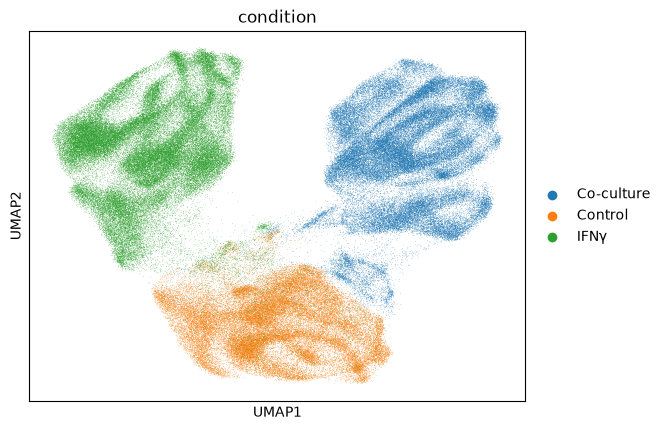

In [5]:
# Create umap colored by condition
sc.pp.neighbors(adata, use_rep='X_pca')
sc.tl.umap(adata)
sc.pl.umap(adata, color="condition")

In [6]:
def compute_pseudobulk_lfc(
    adata: ad.AnnData,
    cond_key: str = 'condition',
    pert_key: str = 'perturbation',
    control_label: str = 'control'
) -> ad.AnnData:
    """Aggregates single-cell data to pseudobulk profiles by condition and perturbation, computes log2 fold changes relative to unperturbed controls per condition, and returns a new pseudobulk AnnData object."""
    # Aggregate single cells using scanpy
    pbulk_adata = sc.get.aggregate(
        adata, 
        by=[cond_key, pert_key], 
        func='mean'
    )
    
    # Re-assign aggregated mean array to .X
    pbulk_adata.X = pbulk_adata.layers['mean'].copy()
    del pbulk_adata.layers['mean']
    
    # Extract aggregated expression matrix as a DataFrame for vectorized ops
    df_expr = pbulk_adata.to_df()
    df_obs = pbulk_adata.obs.copy()
    
    # Vectorized LFC calculation per condition
    lfc_dfs = []
    obs_dfs = []
    
    for cond_val, group_obs in df_obs.groupby(cond_key):
        group_idx = group_obs.index
        group_expr = df_expr.loc[group_idx]
        
        # Locate the control profile for this specific condition
        is_ctrl = group_obs[pert_key] == control_label
        if not is_ctrl.any():
            continue
            
        ctrl_vector = group_expr[is_ctrl].iloc[0]
        
        # Filter out control entries from the final LFC result
        pert_mask = ~is_ctrl
        if not pert_mask.any():
            continue
            
        # Subtract control vector across all non-control perturbations (vectorized)
        lfc_matrix = group_expr[pert_mask].sub(ctrl_vector, axis=1)
        
        lfc_dfs.append(lfc_matrix)
        obs_dfs.append(group_obs[pert_mask])
        
    # Combine results
    final_lfc_df = pd.concat(lfc_dfs, axis=0)
    final_obs_df = pd.concat(obs_dfs, axis=0)
    
    # Wrap LFC result in a clean AnnData object
    lfc_adata = ad.AnnData(
        X=final_lfc_df.values,
        obs=final_obs_df,
        var=pbulk_adata.var.copy()
    )
    lfc_adata.uns['lfc_baseline_label'] = control_label
    
    return lfc_adata

## Cluster all condition together

In [7]:
lfc_adata = compute_pseudobulk_lfc(
    adata, 
    cond_key='condition',  
    pert_key='perturbation',    
    control_label='control'  
)

In [8]:
# Subset anndata to Highly Variable Genes (HVGs) to reduce noise
lfc_adata_hvg = lfc_adata[:, lfc_adata.var['highly_variable']]

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


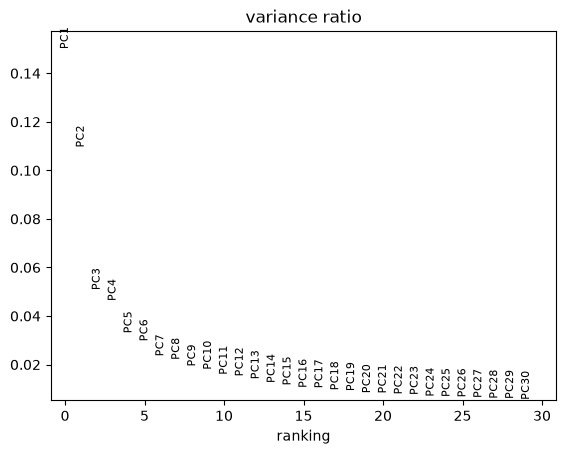

In [9]:
# Find optimal number of PCs to use for clustering using the elbow method
sc.pp.pca(lfc_adata_hvg, n_comps=30)
sc.pl.pca_variance_ratio(lfc_adata_hvg, n_pcs=30, log=False)

In [10]:
# Perform PCA, compute neighbors, and run Leiden clustering on the pseudobulk LFC data
sc.pp.pca(lfc_adata_hvg, n_comps=7)
sc.pp.neighbors(lfc_adata_hvg)
sc.tl.leiden(lfc_adata_hvg)

/tmp/ipykernel_102941/2152543856.py:4: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(lfc_adata_hvg)


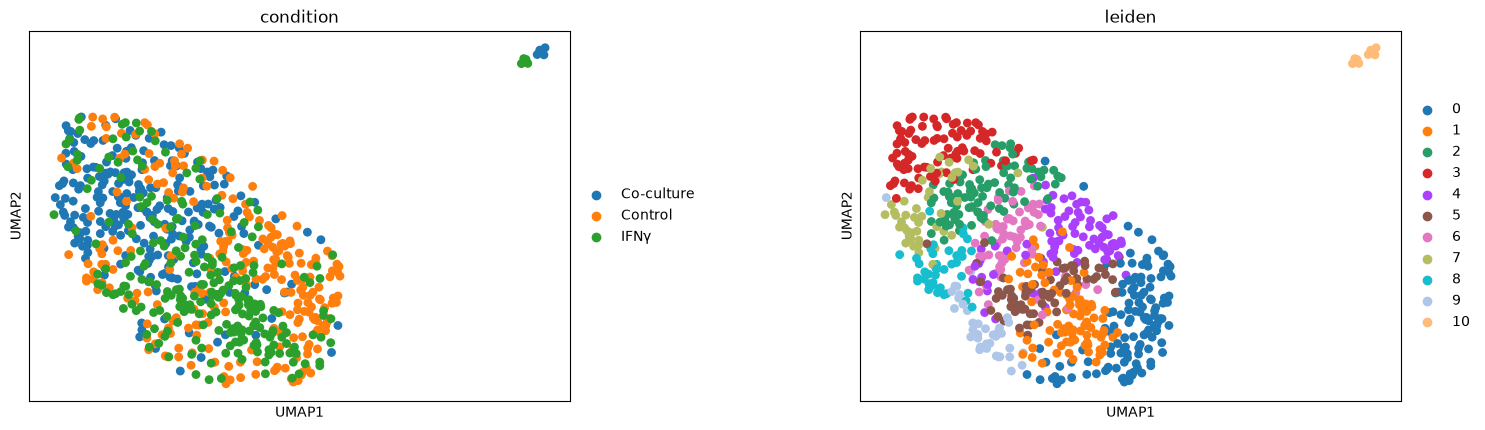

In [11]:
sc.tl.umap(lfc_adata_hvg)
sc.pl.umap(lfc_adata_hvg, color=['condition', 'leiden'], wspace=0.4)

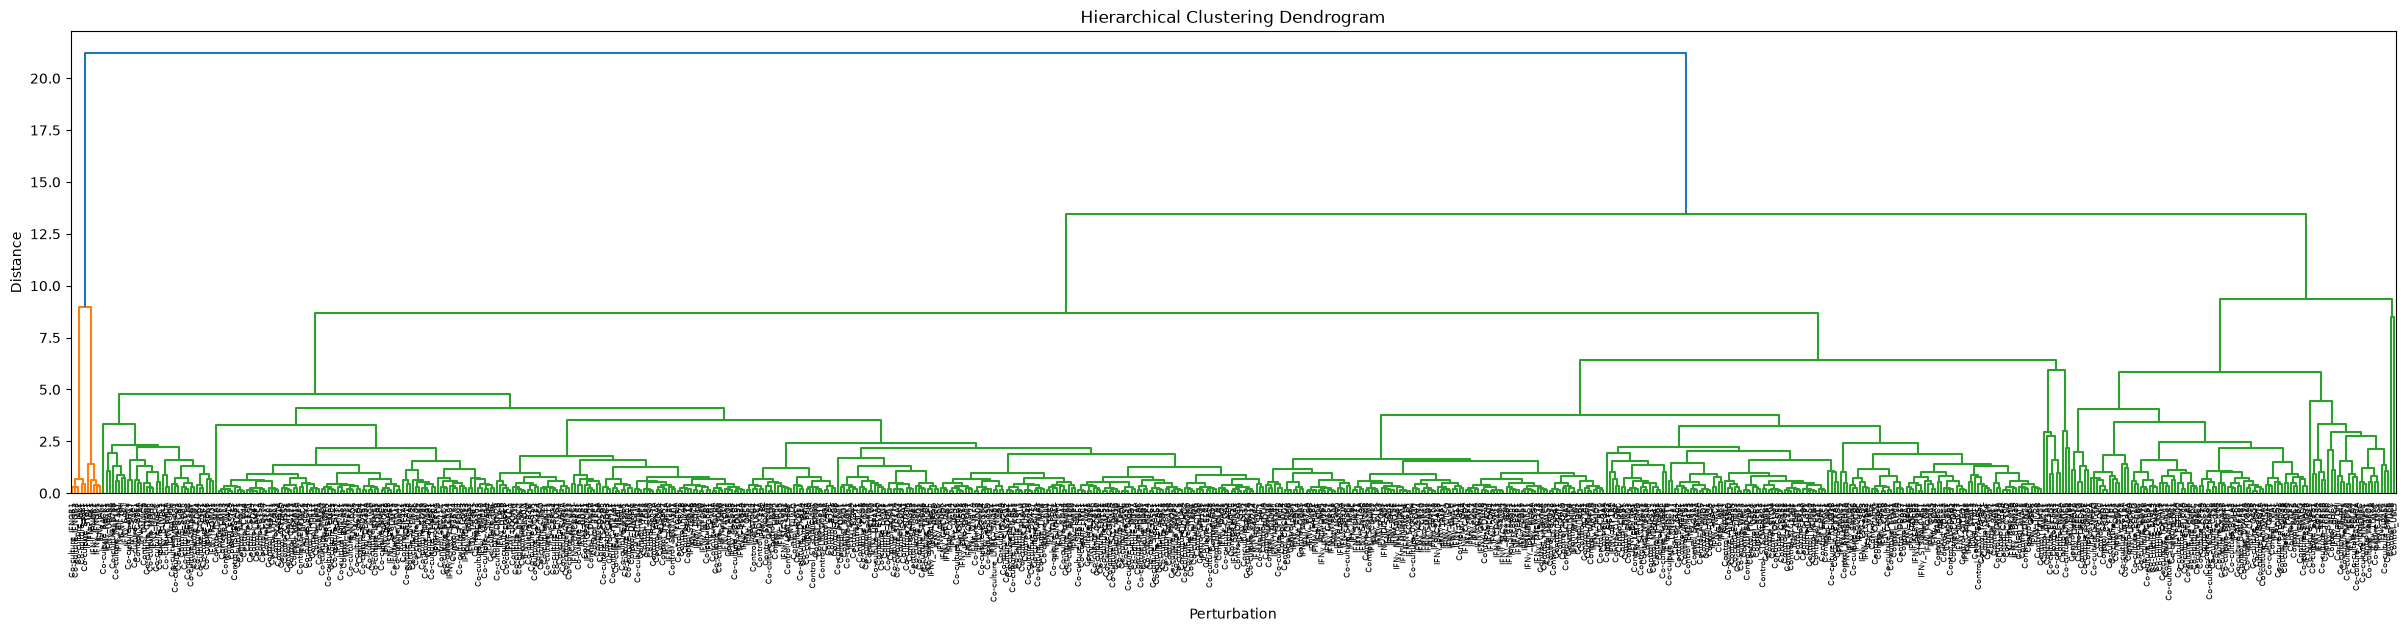

In [12]:
# --- Hierarchical Clustering ---
linkage_data = linkage(lfc_adata_hvg.obsm['X_pca'], method='ward', metric='euclidean')

plt.figure(figsize=(30, 6))

dendrogram(linkage_data, color_threshold=15, labels=lfc_adata_hvg.obs.index, leaf_rotation=90, leaf_font_size=6)

plt.xlabel("Perturbation")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram")

plt.show()

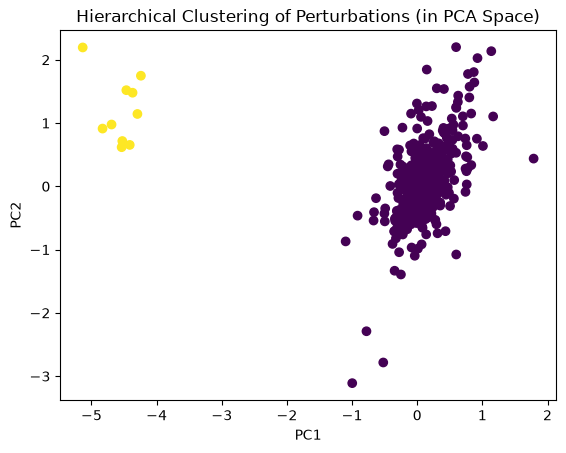

In [13]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
lfc_adata_hvg.obs['cluster_pca_hierarchical'] = hierarchical_cluster.fit_predict(lfc_adata_hvg.obsm['X_pca'])

plt.scatter(lfc_adata_hvg.obsm['X_pca'][:, 0], lfc_adata_hvg.obsm['X_pca'][:, 1], c=lfc_adata_hvg.obs['cluster_pca_hierarchical'])
plt.title("Hierarchical Clustering of Perturbations (in PCA Space)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

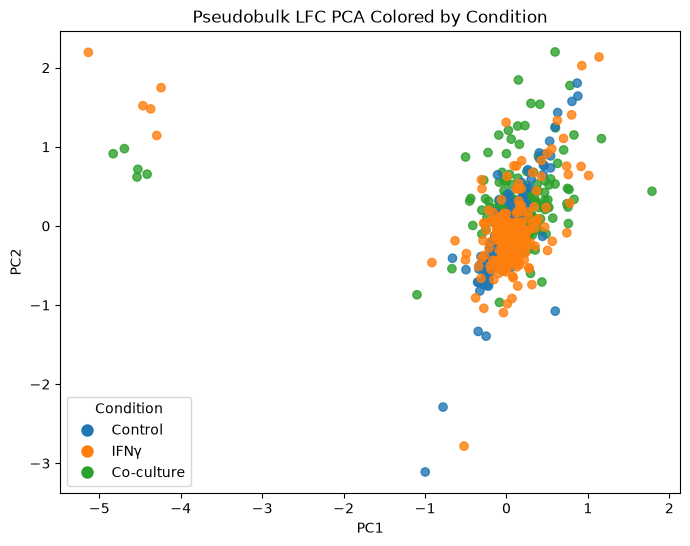

In [14]:
cond_color_map = {
    "Control": "#1f77b4",    # Blue
    "IFNγ": "#ff7f0e",       # Orange
    "Co-culture": "#2ca02c",  # Green
}

# Map the condition string column to hex color codes
colors = lfc_adata_hvg.obs['condition'].map(cond_color_map)

plt.figure(figsize=(8, 6))
plt.scatter(
    lfc_adata_hvg.obsm['X_pca'][:, 0], 
    lfc_adata_hvg.obsm['X_pca'][:, 1], 
    c=colors, 
    alpha=0.8
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Pseudobulk LFC PCA Colored by Condition")
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label=key, markersize=10, markerfacecolor=color) for key, color in cond_color_map.items()], title="Condition")

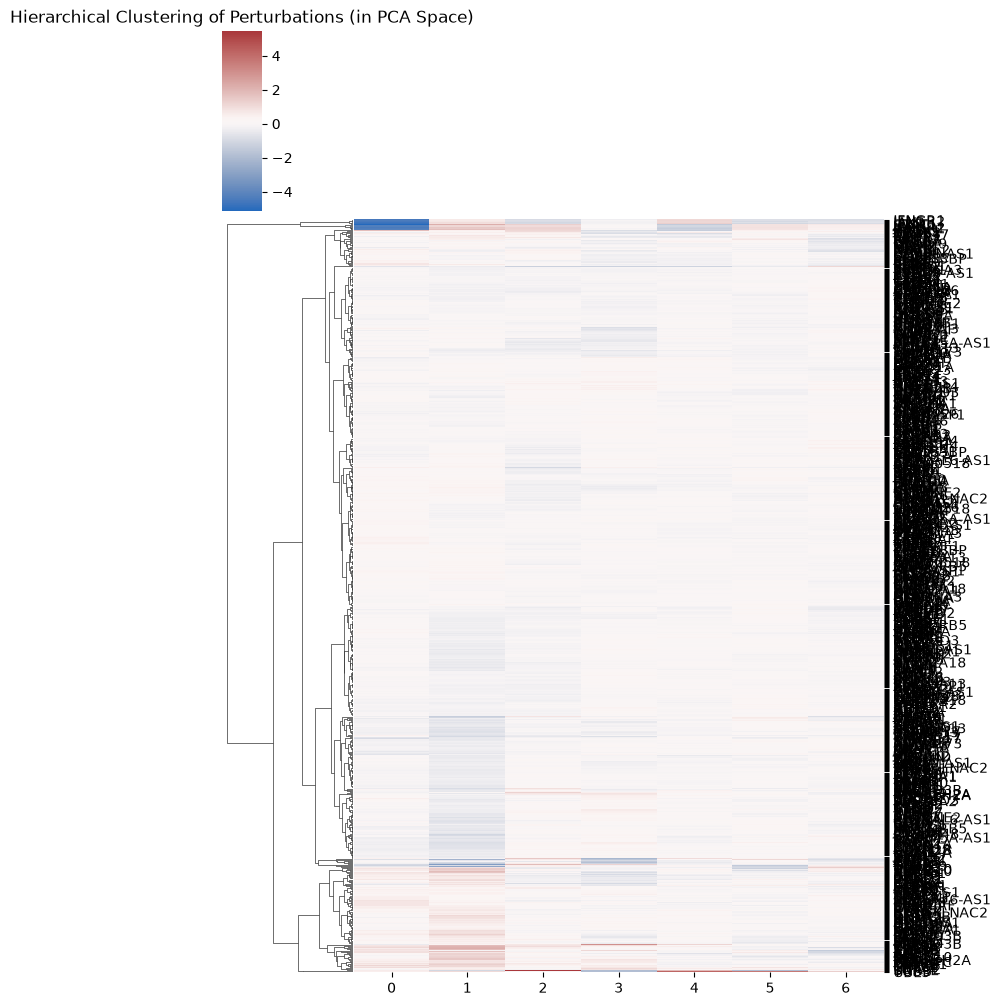

In [15]:
sns.clustermap(
    lfc_adata_hvg.obsm['X_pca'],
    metric='euclidean',
    method='ward',
    col_cluster=False, # PCs don't need reordering on x-axis
    cmap='vlag',
    yticklabels=lfc_adata_hvg.obs['perturbation'].values,
    figsize=(8, 10)
)
plt.title("Hierarchical Clustering of Perturbations (in PCA Space)")
plt.show()

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


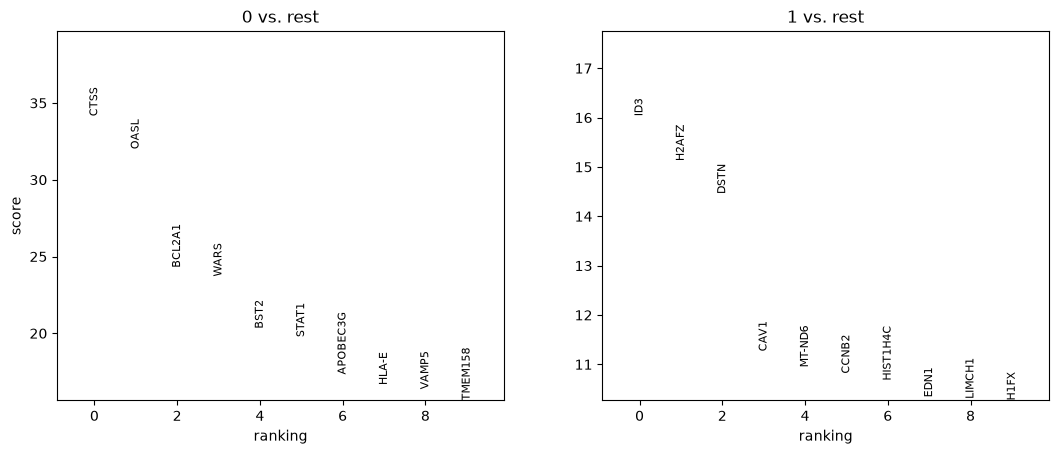

In [16]:
# change to categorical for rank_genes_groups
lfc_adata_hvg.obs['cluster_pca_hierarchical'] = lfc_adata_hvg.obs['cluster_pca_hierarchical'].astype('category')

# Find top driver genes for each perturbation cluster using rank_genes_groups
sc.tl.rank_genes_groups(lfc_adata_hvg, groupby='cluster_pca_hierarchical', method='t-test')

# Visualize top 5 driver genes per cluster
sc.pl.rank_genes_groups(lfc_adata_hvg, n_genes=10, sharey=False)

In [17]:
# Print out the exact perturbation lists in each cluster to see if known pathways co-cluster:
for cluster_id in lfc_adata_hvg.obs['cluster_pca_hierarchical'].unique():
    perturbations_in_cluster = lfc_adata_hvg.obs[
        lfc_adata_hvg.obs['cluster_pca_hierarchical'] == cluster_id
    ]['perturbation'].tolist()
    
    print(f"\n--- Cluster {cluster_id} (Total: {len(perturbations_in_cluster)}) ---")
    print(perturbations_in_cluster[:15])  # Print first 15 perturbations


--- Cluster 0 (Total: 734) ---
['A2M', 'ACSL3', 'ACTA2', 'AEBP1', 'AGA', 'AHCY', 'AHNAK', 'APOC2', 'APOD', 'APOE', 'ARMC6', 'ATP1A1', 'ATP1B1', 'ATP5MD', 'B2M']

--- Cluster 1 (Total: 10) ---
['IFNGR1', 'IFNGR2', 'JAK1', 'JAK2', 'STAT1', 'IFNGR1', 'IFNGR2', 'JAK1', 'JAK2', 'STAT1']


## Cluster condition seperatly

### Control

In [18]:
lfc_adata_control = compute_pseudobulk_lfc(
all_data['control'], 
cond_key='condition',  
pert_key='perturbation',    
control_label='control'  
)

# Subset anndata to Highly Variable Genes (HVGs) to reduce noise
lfc_adata_control_hvg = lfc_adata_control[:, lfc_adata_control.var['highly_variable']]


/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


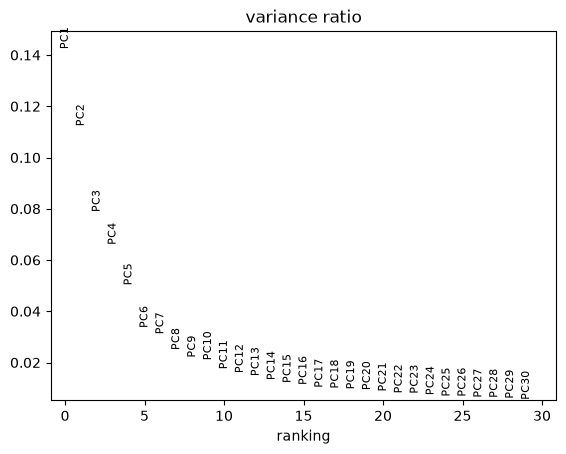

In [19]:
# Find optimal number of PCs to use for clustering using the elbow method
sc.pp.pca(lfc_adata_control_hvg, n_comps=30)
sc.pl.pca_variance_ratio(lfc_adata_control_hvg, n_pcs=30, log=False)

In [20]:
sc.pp.pca(lfc_adata_control_hvg, n_comps=8)

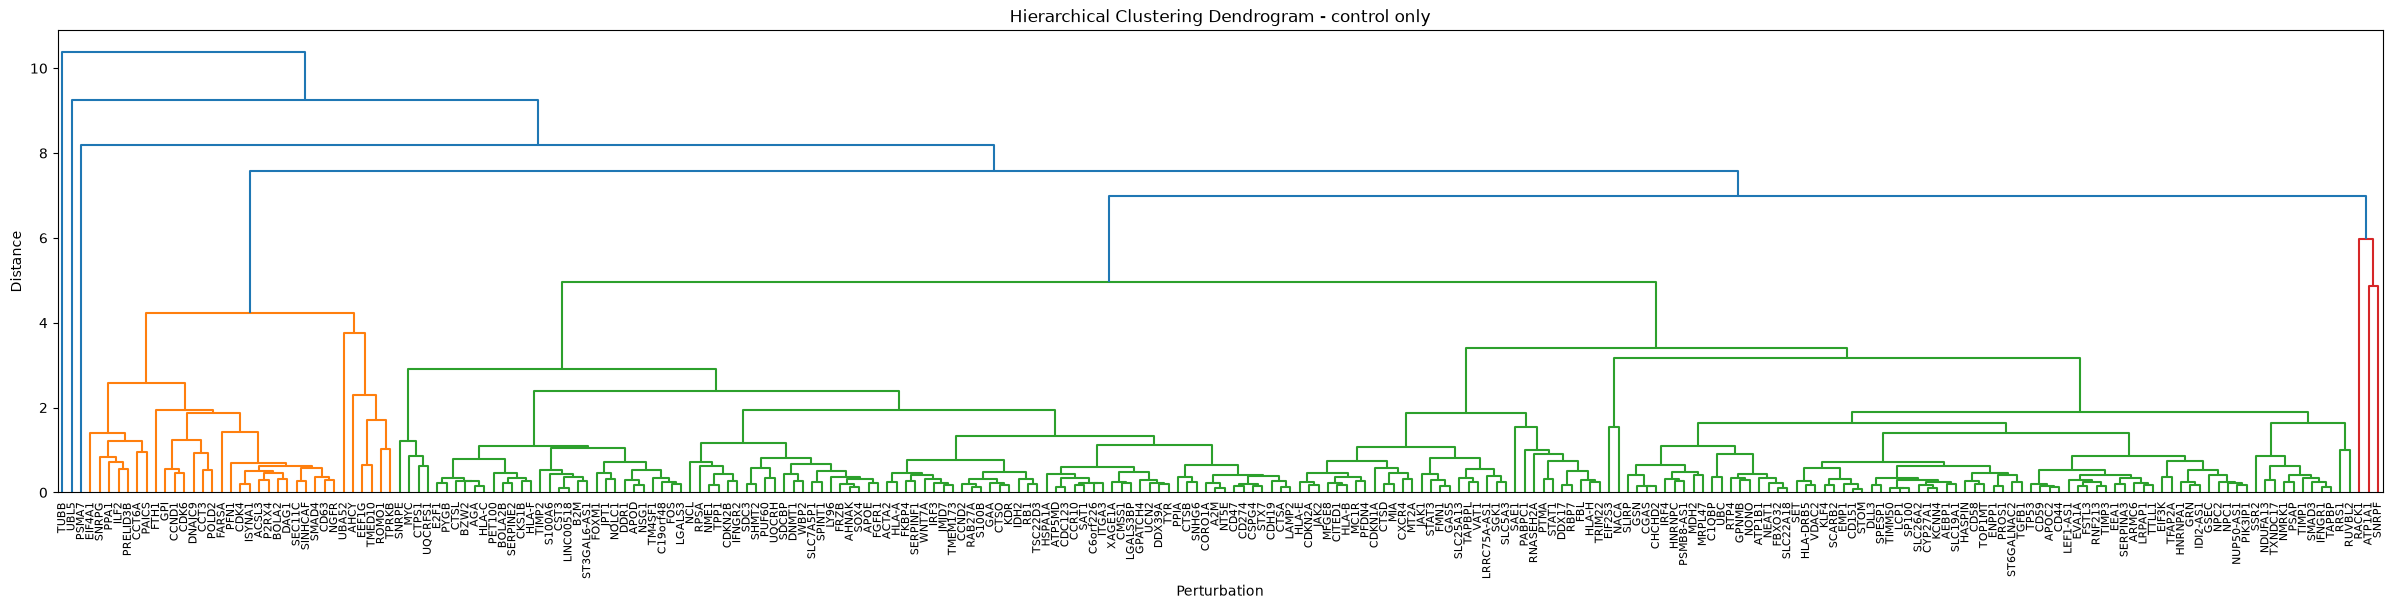

In [21]:
# --- Hierarchical Clustering ---
linkage_data_control = linkage(lfc_adata_control_hvg.obsm['X_pca'], method='ward', metric='euclidean')

plt.figure(figsize=(30, 6))

dendrogram(linkage_data_control, color_threshold=6, labels=lfc_adata_control_hvg.obs["perturbation"].tolist(), leaf_rotation=90, leaf_font_size=8)

plt.xlabel("Perturbation")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram - control only")

plt.show()

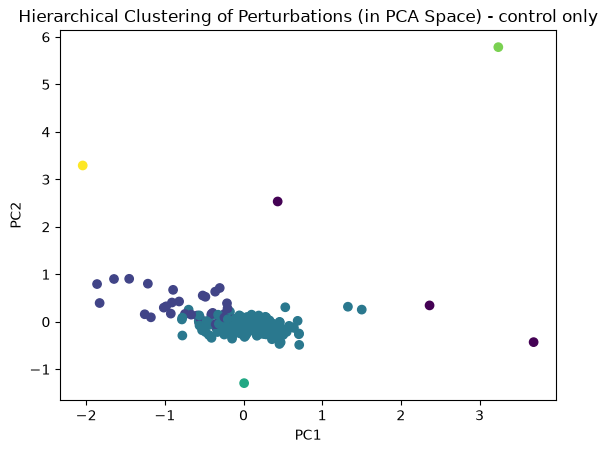

In [33]:
hierarchical_cluster_control = AgglomerativeClustering(n_clusters=6, metric='euclidean', linkage='ward')
lfc_adata_control_hvg.obs['cluster_pca_hierarchical'] = hierarchical_cluster_control.fit_predict(lfc_adata_control_hvg.obsm['X_pca'])

plt.scatter(lfc_adata_control_hvg.obsm['X_pca'][:, 0], lfc_adata_control_hvg.obsm['X_pca'][:, 1], c=lfc_adata_control_hvg.obs['cluster_pca_hierarchical'])
plt.title("Hierarchical Clustering of Perturbations (in PCA Space) - control only")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

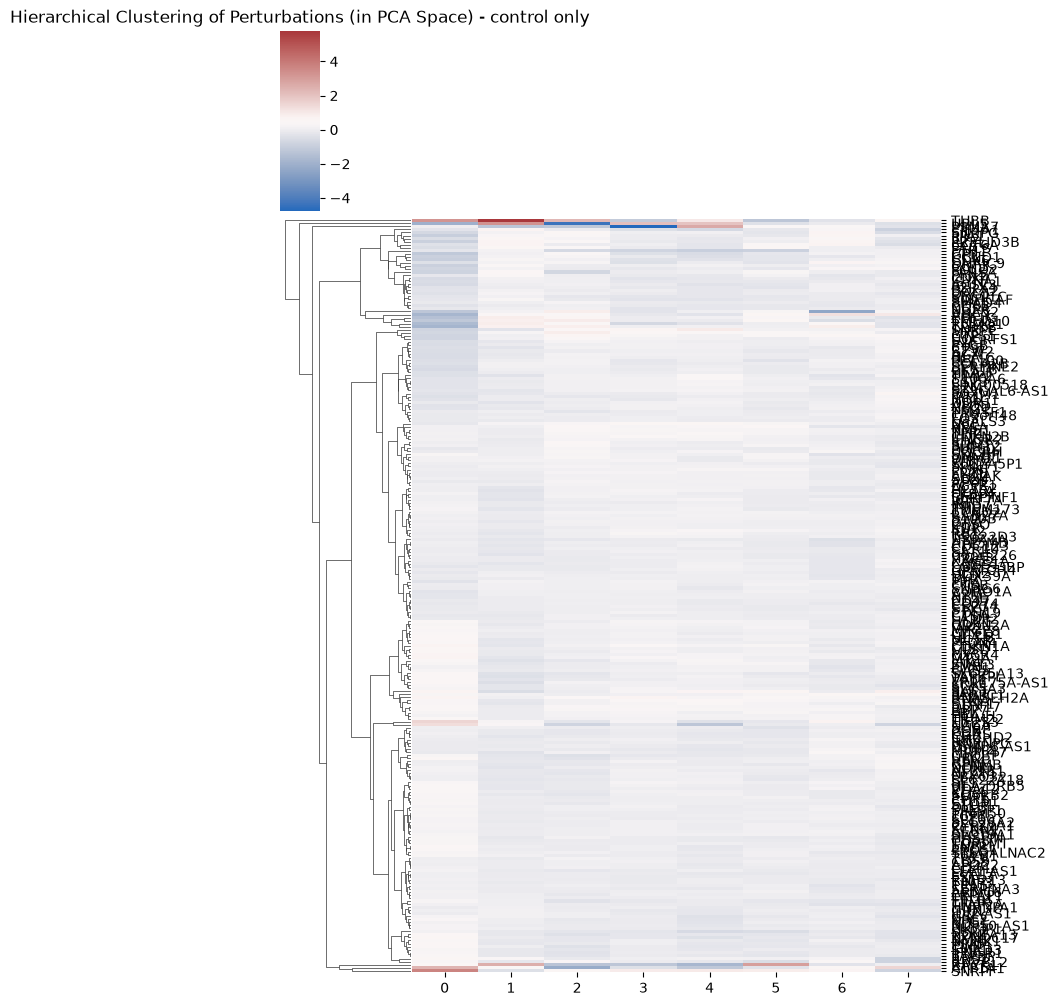

In [23]:
sns.clustermap(
    lfc_adata_control_hvg.obsm['X_pca'],
    metric='euclidean',
    method='ward',
    col_cluster=False, # PCs don't need reordering on x-axis
    cmap='vlag',
    yticklabels=lfc_adata_control_hvg.obs['perturbation'].values,
    figsize=(8, 10)
)
plt.title("Hierarchical Clustering of Perturbations (in PCA Space) - control only")
plt.show()

Valid clusters with > 3 samples: ['2', '1']


/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


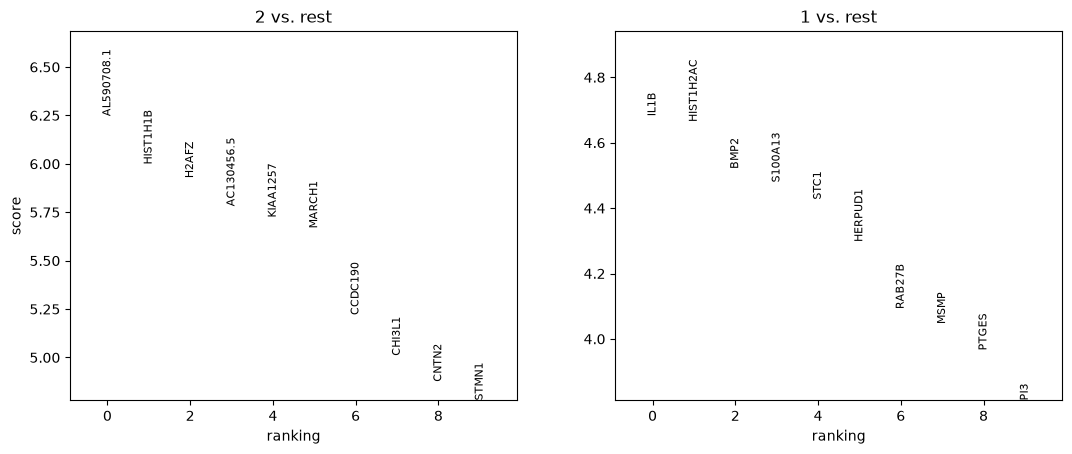

In [42]:
# change to categorical for rank_genes_groups
lfc_adata_control_hvg.obs['cluster_pca_hierarchical'] = lfc_adata_control_hvg.obs['cluster_pca_hierarchical'].astype("str").astype('category')

cluster_counts = lfc_adata_control_hvg.obs['cluster_pca_hierarchical'].value_counts()

valid_groups = cluster_counts[cluster_counts > 3].index.tolist()

print(f"Valid clusters with > 3 samples: {valid_groups}")

# Find top driver genes for each perturbation cluster using rank_genes_groups
sc.tl.rank_genes_groups(lfc_adata_control_hvg, groupby='cluster_pca_hierarchical', groups=valid_groups, method='t-test')

# Visualize top 5 driver genes per cluster
sc.pl.rank_genes_groups(lfc_adata_control_hvg, n_genes=10, sharey=False)

In [43]:
# Print out the exact perturbation lists in each cluster to see if known pathways co-cluster:
for cluster_id in lfc_adata_control_hvg.obs['cluster_pca_hierarchical'].unique():
    perturbations_in_cluster = lfc_adata_control_hvg.obs[
        lfc_adata_control_hvg.obs['cluster_pca_hierarchical'] == cluster_id
    ]['perturbation'].tolist()
    
    print(f"\n--- Cluster {cluster_id} (Total: {len(perturbations_in_cluster)}) ---")
    print(perturbations_in_cluster[:15])  # Print first 15 perturbations


--- Cluster 2 (Total: 209) ---
['A2M', 'ACTA2', 'AEBP1', 'AGA', 'AHNAK', 'APOC2', 'APOD', 'APOE', 'ARMC6', 'ATP1B1', 'ATP5MD', 'B2M', 'BOLA2B', 'BZW2', 'C1QBP']

--- Cluster 1 (Total: 33) ---
['ACSL3', 'AHCY', 'BOLA2', 'CCND1', 'CCT3', 'CCT6A', 'CD63', 'CDK4', 'CDK6', 'DAG1', 'DNAJC9', 'EEF1G', 'EIF4A1', 'FARSA', 'FTH1']

--- Cluster 0 (Total: 3) ---
['ATP1A1', 'RACK1', 'SNRPF']

--- Cluster 3 (Total: 1) ---
['PSMA7']

--- Cluster 4 (Total: 1) ---
['TUBB']

--- Cluster 5 (Total: 1) ---
['UBL5']


### co-culture

In [45]:
lfc_adata_coculture = compute_pseudobulk_lfc(
all_data['coculture'], 
cond_key='condition',  
pert_key='perturbation',    
control_label='control'  
)

# Subset anndata to Highly Variable Genes (HVGs) to reduce noise
lfc_adata_coculture_hvg = lfc_adata_coculture[:, lfc_adata_coculture.var['highly_variable']]


/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


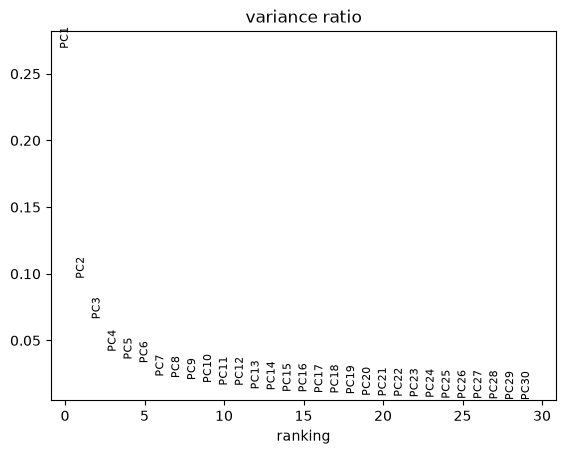

In [46]:
# Find optimal number of PCs to use for clustering using the elbow method
sc.pp.pca(lfc_adata_coculture_hvg, n_comps=30)
sc.pl.pca_variance_ratio(lfc_adata_coculture_hvg, n_pcs=30, log=False)

In [47]:
sc.pp.pca(lfc_adata_coculture_hvg, n_comps=7)

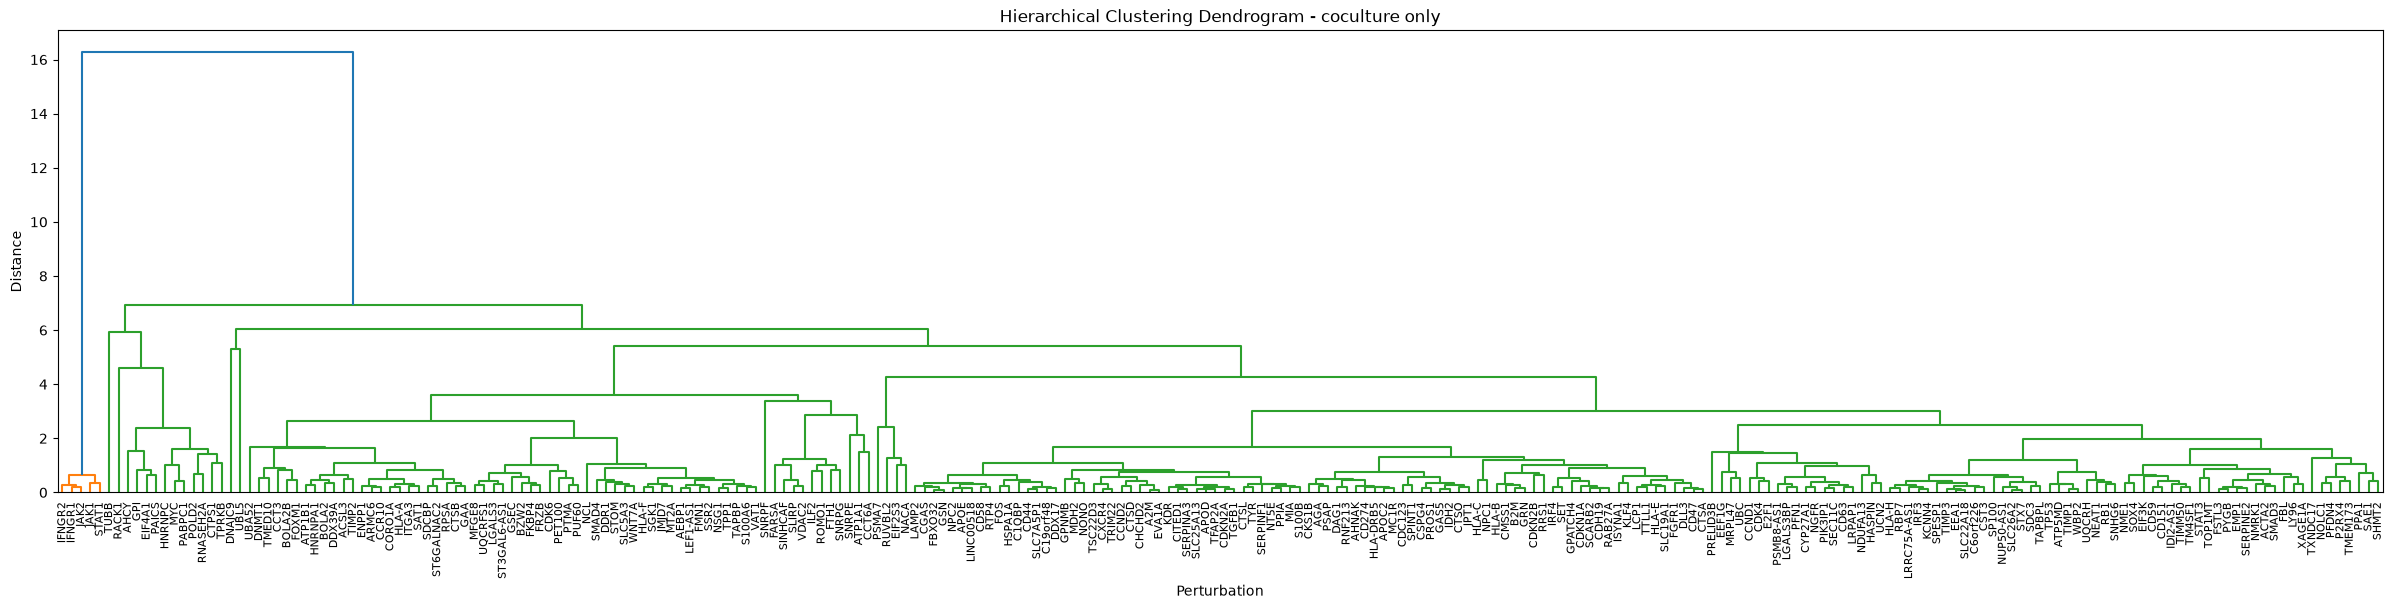

In [48]:
# --- Hierarchical Clustering ---
linkage_data_coculture = linkage(lfc_adata_coculture_hvg.obsm['X_pca'], method='ward', metric='euclidean')

plt.figure(figsize=(30, 6))

dendrogram(linkage_data_coculture, color_threshold=8, labels=lfc_adata_coculture_hvg.obs["perturbation"].tolist(), leaf_rotation=90, leaf_font_size=8)

plt.xlabel("Perturbation")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram - coculture only")

plt.show()

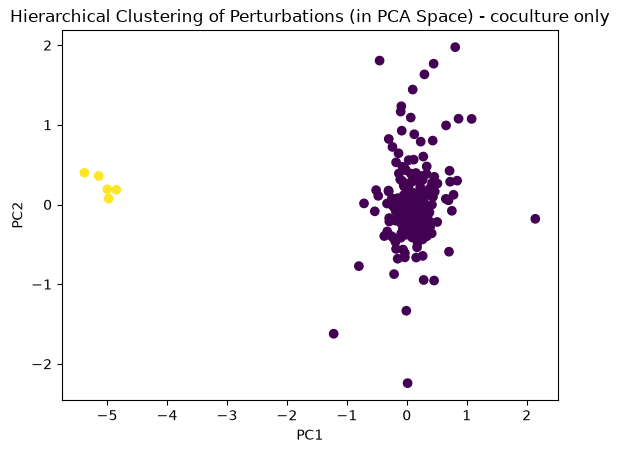

In [49]:
hierarchical_cluster_coculture = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
lfc_adata_coculture_hvg.obs['cluster_pca_hierarchical'] = hierarchical_cluster_coculture.fit_predict(lfc_adata_coculture_hvg.obsm['X_pca'])

plt.scatter(lfc_adata_coculture_hvg.obsm['X_pca'][:, 0], lfc_adata_coculture_hvg.obsm['X_pca'][:, 1], c=lfc_adata_coculture_hvg.obs['cluster_pca_hierarchical'])
plt.title("Hierarchical Clustering of Perturbations (in PCA Space) - coculture only")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

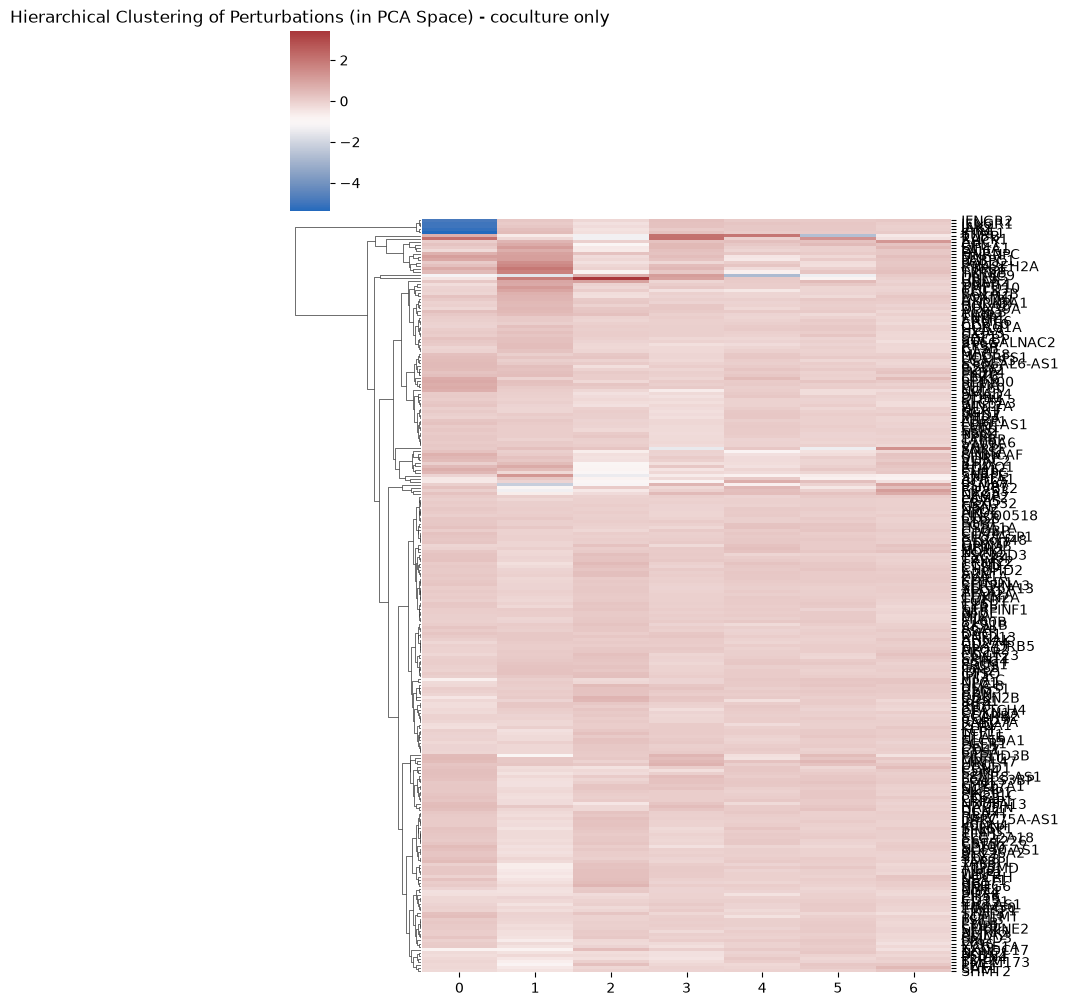

In [50]:
sns.clustermap(
    lfc_adata_coculture_hvg.obsm['X_pca'],
    metric='euclidean',
    method='ward',
    col_cluster=False, # PCs don't need reordering on x-axis
    cmap='vlag',
    yticklabels=lfc_adata_coculture_hvg.obs['perturbation'].values,
    figsize=(8, 10)
)
plt.title("Hierarchical Clustering of Perturbations (in PCA Space) - coculture only")
plt.show()

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


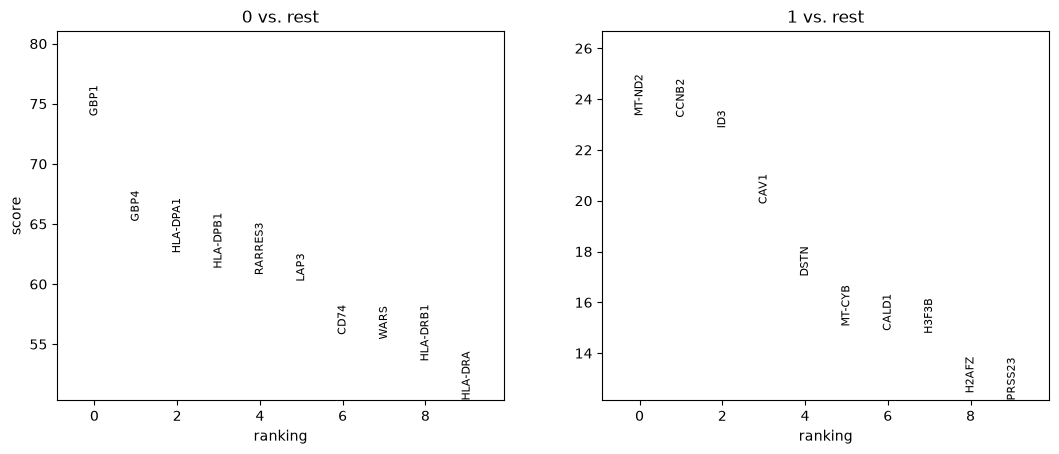

In [ ]:
# change to categorical for rank_genes_groups
lfc_adata_coculture_hvg.obs['cluster_pca_hierarchical'] = lfc_adata_coculture_hvg.obs['cluster_pca_hierarchical'].astype("str").astype('category')

# Find top driver genes for each perturbation cluster using rank_genes_groups
sc.tl.rank_genes_groups(lfc_adata_coculture_hvg, groupby='cluster_pca_hierarchical', method='t-test')

# Visualize top 5 driver genes per cluster
sc.pl.rank_genes_groups(lfc_adata_coculture_hvg, n_genes=10, sharey=False)

In [53]:
# Print out the exact perturbation lists in each cluster to see if known pathways co-cluster:
for cluster_id in lfc_adata_coculture_hvg.obs['cluster_pca_hierarchical'].unique():
    perturbations_in_cluster = lfc_adata_coculture_hvg.obs[
        lfc_adata_coculture_hvg.obs['cluster_pca_hierarchical'] == cluster_id
    ]['perturbation'].tolist()
    
    print(f"\n--- Cluster {cluster_id} (Total: {len(perturbations_in_cluster)}) ---")
    print(perturbations_in_cluster[:15])  # Print first 15 perturbations


--- Cluster 0 (Total: 243) ---
['A2M', 'ACSL3', 'ACTA2', 'AEBP1', 'AGA', 'AHCY', 'AHNAK', 'APOC2', 'APOD', 'APOE', 'ARMC6', 'ATP1A1', 'ATP1B1', 'ATP5MD', 'B2M']

--- Cluster 1 (Total: 5) ---
['IFNGR1', 'IFNGR2', 'JAK1', 'JAK2', 'STAT1']


### IFNg

In [54]:
lfc_adata_ifng = compute_pseudobulk_lfc(
all_data['ifng'], 
cond_key='condition',  
pert_key='perturbation',    
control_label='control'  
)

# Subset anndata to Highly Variable Genes (HVGs) to reduce noise
lfc_adata_ifng_hvg = lfc_adata_ifng[:, lfc_adata_ifng.var['highly_variable']]


/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:359: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


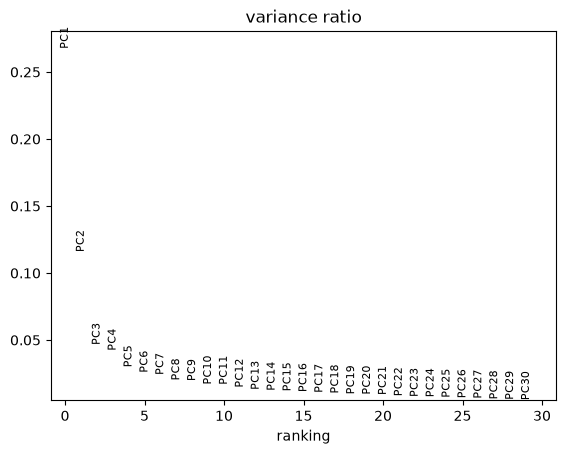

In [55]:
# Find optimal number of PCs to use for clustering using the elbow method
sc.pp.pca(lfc_adata_ifng_hvg, n_comps=30)
sc.pl.pca_variance_ratio(lfc_adata_ifng_hvg, n_pcs=30, log=False)

In [56]:
sc.pp.pca(lfc_adata_ifng_hvg, n_comps=5)

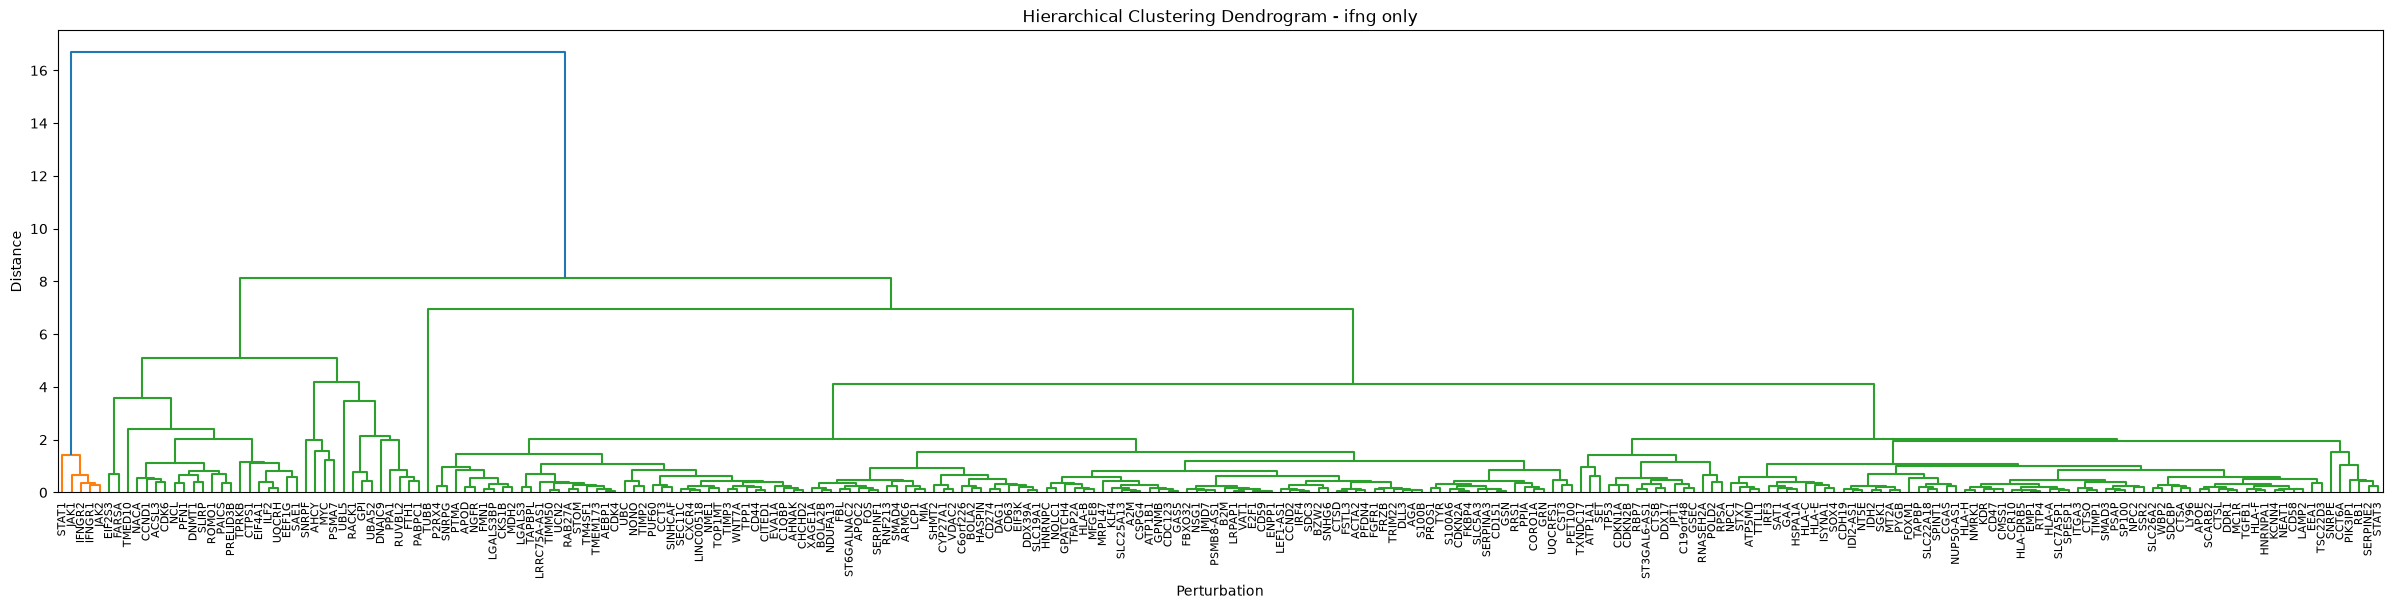

In [57]:
# --- Hierarchical Clustering ---
linkage_data_ifng = linkage(lfc_adata_ifng_hvg.obsm['X_pca'], method='ward', metric='euclidean')

plt.figure(figsize=(30, 6))

dendrogram(linkage_data_ifng, color_threshold=10, labels=lfc_adata_ifng_hvg.obs["perturbation"].tolist(), leaf_rotation=90, leaf_font_size=8)

plt.xlabel("Perturbation")
plt.ylabel("Distance")
plt.title("Hierarchical Clustering Dendrogram - ifng only")

plt.show()

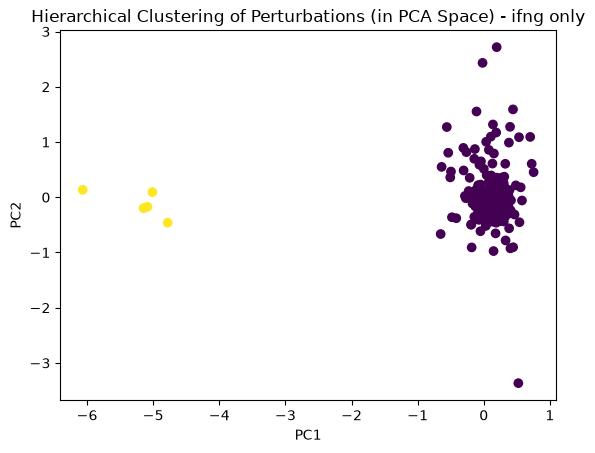

In [58]:
hierarchical_cluster_ifng = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='ward')
lfc_adata_ifng_hvg.obs['cluster_pca_hierarchical'] = hierarchical_cluster_ifng.fit_predict(lfc_adata_ifng_hvg.obsm['X_pca'])

plt.scatter(lfc_adata_ifng_hvg.obsm['X_pca'][:, 0], lfc_adata_ifng_hvg.obsm['X_pca'][:, 1], c=lfc_adata_ifng_hvg.obs['cluster_pca_hierarchical'])
plt.title("Hierarchical Clustering of Perturbations (in PCA Space) - ifng only")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

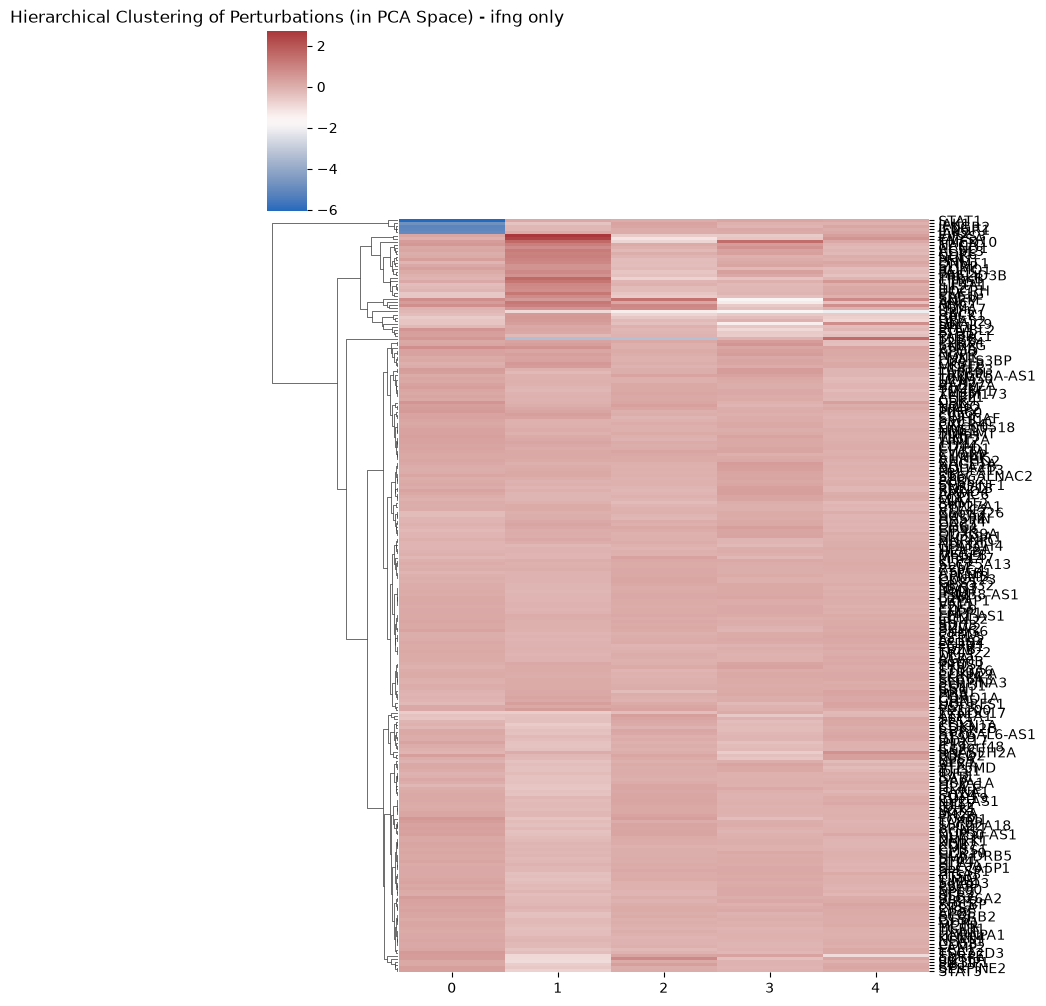

In [59]:
sns.clustermap(
    lfc_adata_ifng_hvg.obsm['X_pca'],
    metric='euclidean',
    method='ward',
    col_cluster=False, # PCs don't need reordering on x-axis
    cmap='vlag',
    yticklabels=lfc_adata_ifng_hvg.obs['perturbation'].values,
    figsize=(8, 10)
)
plt.title("Hierarchical Clustering of Perturbations (in PCA Space) - ifng only")
plt.show()

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


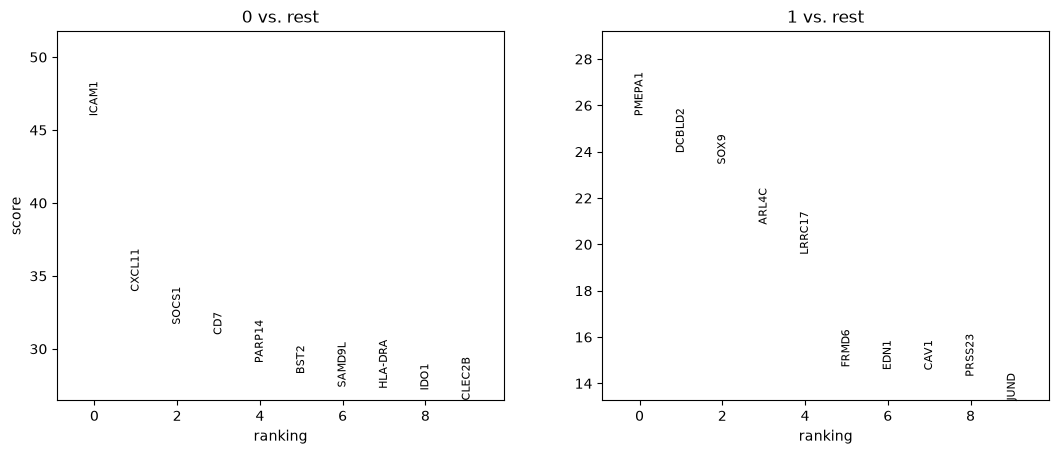

In [60]:
# change to categorical for rank_genes_groups
lfc_adata_ifng_hvg.obs['cluster_pca_hierarchical'] = lfc_adata_ifng_hvg.obs['cluster_pca_hierarchical'].astype("str").astype('category')

# Find top driver genes for each perturbation cluster using rank_genes_groups
sc.tl.rank_genes_groups(lfc_adata_ifng_hvg, groupby='cluster_pca_hierarchical', method='t-test')

# Visualize top 5 driver genes per cluster
sc.pl.rank_genes_groups(lfc_adata_ifng_hvg, n_genes=10, sharey=False)

In [61]:
# Print out the exact perturbation lists in each cluster to see if known pathways co-cluster:
for cluster_id in lfc_adata_ifng_hvg.obs['cluster_pca_hierarchical'].unique():
    perturbations_in_cluster = lfc_adata_ifng_hvg.obs[
        lfc_adata_ifng_hvg.obs['cluster_pca_hierarchical'] == cluster_id
    ]['perturbation'].tolist()
    
    print(f"\n--- Cluster {cluster_id} (Total: {len(perturbations_in_cluster)}) ---")
    print(perturbations_in_cluster[:15])  # Print first 15 perturbations


--- Cluster 0 (Total: 243) ---
['A2M', 'ACSL3', 'ACTA2', 'AEBP1', 'AGA', 'AHCY', 'AHNAK', 'APOC2', 'APOD', 'APOE', 'ARMC6', 'ATP1A1', 'ATP1B1', 'ATP5MD', 'B2M']

--- Cluster 1 (Total: 5) ---
['IFNGR1', 'IFNGR2', 'JAK1', 'JAK2', 'STAT1']
